## AI Usage

AI was used in the development for the inspiration of a portion of this code. The sampling technique used for Manhattan plot generation uses a clever method to unify an array of all significant SNPs and sampled non-significant SNPs using the seed of 42. AI was also used to modernize the text overlay on the Manhattan plot as well and adjust this text to ensure there is no overlap. Lastly, AI was used in the slightly different but similar sampling for the QQ plot generation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv('/Users/kyle/Documents/Occidental/Computational Biology/Final Project/Data/GCST90297790.tsv', sep='\t')
df['-logp'] = - np.log10(df['p_value'])

running_pos = 0
cumulative_pos = []
for chrom, group_df in df.groupby('chromosome'):
    cumulative_pos.append(group_df['base_pair_location'] + running_pos)
    running_pos += group_df['base_pair_location'].max()
df['cumulative_pos'] = pd.concat(cumulative_pos)

## Problem with Manhattan Plot

Up to this point, I've been able to follow the code essentially as it was written for Lab 5 during our GWAS analysis of risky behavior. Here, though, I run into a problem because the data from the .tsv file is not sorted by chromosome as our previous data was. Instead, the data is lexicographically sorted where 10-19 all come before chromosome 2.
___
##### To fix this, I will re-sort the data by their numeric chromosome values rather than lexicographic sorting

In [3]:
df = df.sort_values(['chromosome', 'base_pair_location'])
df # Verification. Note that the index is retained from the original file (evidenced by the low numbers for the last few lines) so we will need to reset the index

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,cumulative_pos
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,49298
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,54353
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,54712
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,55326
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,58814
...,...,...,...,...,...,...,...,...,...,...,...,...
3945923,23,156007058,A,G,-0.000654,0.012252,0.39987,0.957421,chrX_156007058_A_G,0.58246,0.018897,3029544453
3945924,23,156009119,C,G,0.100992,0.060377,0.36794,0.094402,chrX_156009119_G_C,0.02615,1.025017,3029546514
3945925,23,156017071,A,G,-0.063765,0.058965,0.03553,0.279537,chrX_156017071_G_A,0.18801,0.553561,3029554466
3945926,23,156021847,G,A,0.087328,0.131210,0.05141,0.505701,chrX_156021847_A_G,0.02569,0.296106,3029559242


In [4]:
df = df.reset_index(drop=True)
df['SNP Number_Updated'] = df.index
df

,chromosome,base_pair_location,effect_allele,other_allele,beta,standard_error,effect_allele_frequency,p_value,rs_id,info,-logp,cumulative_pos,SNP Number_Updated
0,1,49298,T,C,-0.286429,0.278038,0.00682,0.302937,rs10399793,0.04320,0.518648,49298,0
1,1,54353,A,C,-0.546315,1.173490,0.00971,0.641545,rs140052487,0.00161,0.192773,54353,1
2,1,54712,C,T,-1.266810,1.517310,0.01544,0.403780,rs773293602,0.00048,0.393855,54712,2
3,1,55326,C,T,2.805280,2.578980,0.04431,0.276720,rs3107975,0.00004,0.557959,55326,3
4,1,58814,A,G,-0.433076,0.430802,0.00370,0.314774,rs114420996,1.00000,0.502001,58814,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6788335,23,156007058,A,G,-0.000654,0.012252,0.39987,0.957421,chrX_156007058_A_G,0.58246,0.018897,3029544453,6788335
6788336,23,156009119,C,G,0.100992,0.060377,0.36794,0.094402,chrX_156009119_G_C,0.02615,1.025017,3029546514,6788336
6788337,23,156017071,A,G,-0.063765,0.058965,0.03553,0.279537,chrX_156017071_G_A,0.18801,0.553561,3029554466,6788337
6788338,23,156021847,G,A,0.087328,0.131210,0.05141,0.505701,chrX_156021847_A_G,0.02569,0.296106,3029559242,6788338


/var/folders/g1/bq464l1n5lb9nlrdwm5bgtdm0000gn/T/ipykernel_4598/2656085754.py:15: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


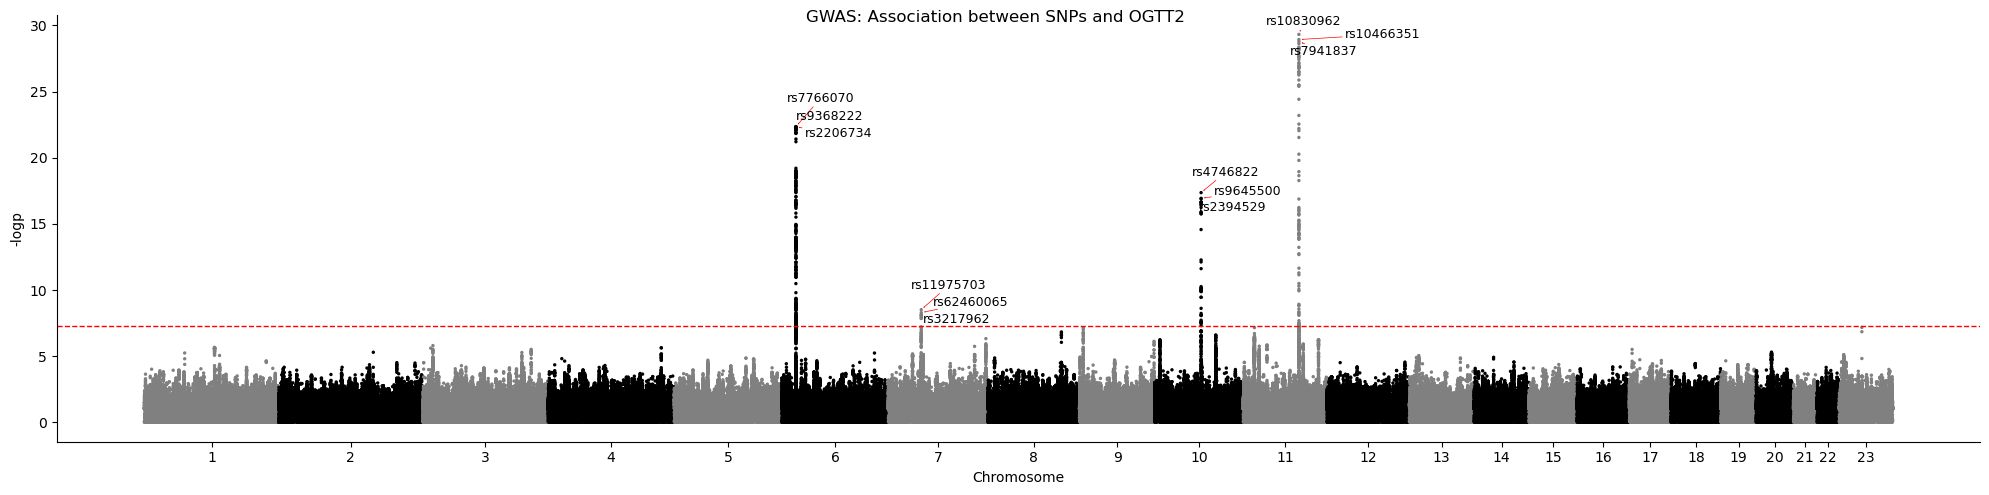

In [5]:
# Addition of text and sampling for more efficient code

import adjustText
from adjustText import adjust_text

# Thinning the data
sig_snps = df[df['-logp'] > 1] # AI Generated
non_sig_snps = df[df['-logp'] <= 5].sample(frac=0.01, random_state=42) # AI Generated
# Just learned that the random_state of 42 is a reference to one of my favorite books Hitchiker's Guide to the Galaxy!

# Combining
all_snps = pd.concat([sig_snps, non_sig_snps]).sort_values('SNP Number_Updated')

# Plotting
g = sns.relplot(
    data = all_snps,
    x = 'SNP Number_Updated',
    y = '-logp',
    aspect = 4,
    hue = 'chromosome',
    palette = ['grey', 'black'] * 11,
    linewidth = 0,
    s = 6,
    legend=None
)

# Finding top 3 SNPs per chromosome to label
# We group by chromosome and take the top 3 largest -logp values
top_snps = (all_snps[all_snps['-logp'] > 7.30] # Only consider genome-wide significant
            .sort_values('-logp', ascending=False) # Sort by p-value
            .groupby('chromosome') # Group by chromosome
            .head(3)) # Pick the top three SNPs from each chromosome that are above 5e-8
# This ^ code was AI inspired but not AI generated. AI was used to help me think how to plot only a few SNPs from each linkage disequilibrium

# Adding Annotations
texts = []
for i, row in top_snps.iterrows():
    texts.append(g.ax.text(row['SNP Number_Updated'], row['-logp'], row['rs_id'], fontsize=9))
# This loop was AI generated. The previous code for adding text to our plots would not work, even with updated parameters.

# Styling the plot
g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['SNP Number_Updated'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS: Association between SNPs and OGTT2')

# Adding a significance line
g.ax.axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=1)

# Adjust text to prevent overlap
adjust_text(texts, arrowprops={'arrowstyle': '->', 'color': 'red', 'lw': 0.5})

plt.show()

In [6]:
# Verification
summary = top_snps[['chromosome', 'base_pair_location', 'rs_id', '-logp', 'effect_allele', 'other_allele', 'beta']]
summary

,chromosome,base_pair_location,rs_id,-logp,effect_allele,other_allele,beta
4482924,11,92965261,rs10830962,29.324226,G,C,0.145804
4482923,11,92964815,rs10466351,28.933585,T,C,0.134488
4482925,11,92966500,rs7941837,28.784466,T,A,0.141657
2529831,6,20686342,rs7766070,22.354394,A,C,0.106325
2529833,6,20686765,rs9368222,22.342962,A,C,0.107365
2529842,6,20694653,rs2206734,22.328627,T,C,0.107369
4103153,10,69223185,rs4746822,17.363562,T,C,0.114259
4103167,10,69226967,rs9645500,16.932989,G,T,0.116385
4103161,10,69225511,rs2394529,16.892478,C,G,0.118873
3016442,7,44109506,rs11975703,8.515081,A,G,-0.079312


In [7]:
top_snps = (all_snps[all_snps['-logp'] > 7.30]
            .sort_values('-logp', ascending=False)
            .groupby('chromosome')
            .head(50)) # Same code as earlier but switching 3 to 50 to look for greater betas
summary = top_snps[['chromosome', 'base_pair_location', 'rs_id', '-logp', 'effect_allele', 'other_allele', 'beta']]
# Sort from highest beta to lowest
summary_sorted = summary.sort_values('beta', ascending=False)
summary_sorted.head(20)

,chromosome,base_pair_location,rs_id,-logp,effect_allele,other_allele,beta
4482906,11,92951277,rs148099371,24.421013,A,G,6.905860
4482894,11,92946810,rs147794791,23.196200,C,T,6.132790
4482964,11,92992272,rs149733750,22.051299,T,A,5.657620
2529870,6,20717137,rs138401264,21.212641,A,G,3.594250
2529851,6,20710065,rs141244650,22.135758,G,T,2.465200
4482916,11,92959038,rs187404354,16.042979,T,G,2.237670
4103214,10,69235846,rs117975347,11.615833,T,C,1.604690
4482895,11,92947448,rs2166704,25.400825,A,T,1.545970
2529893,6,20725724,rs117267852,21.998007,T,C,1.543710
2529896,6,20726092,rs148143507,21.415877,A,G,1.489710


/var/folders/g1/bq464l1n5lb9nlrdwm5bgtdm0000gn/T/ipykernel_4598/1446851498.py:10: UserWarning: 
The palette list has fewer values (22) than needed (23) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


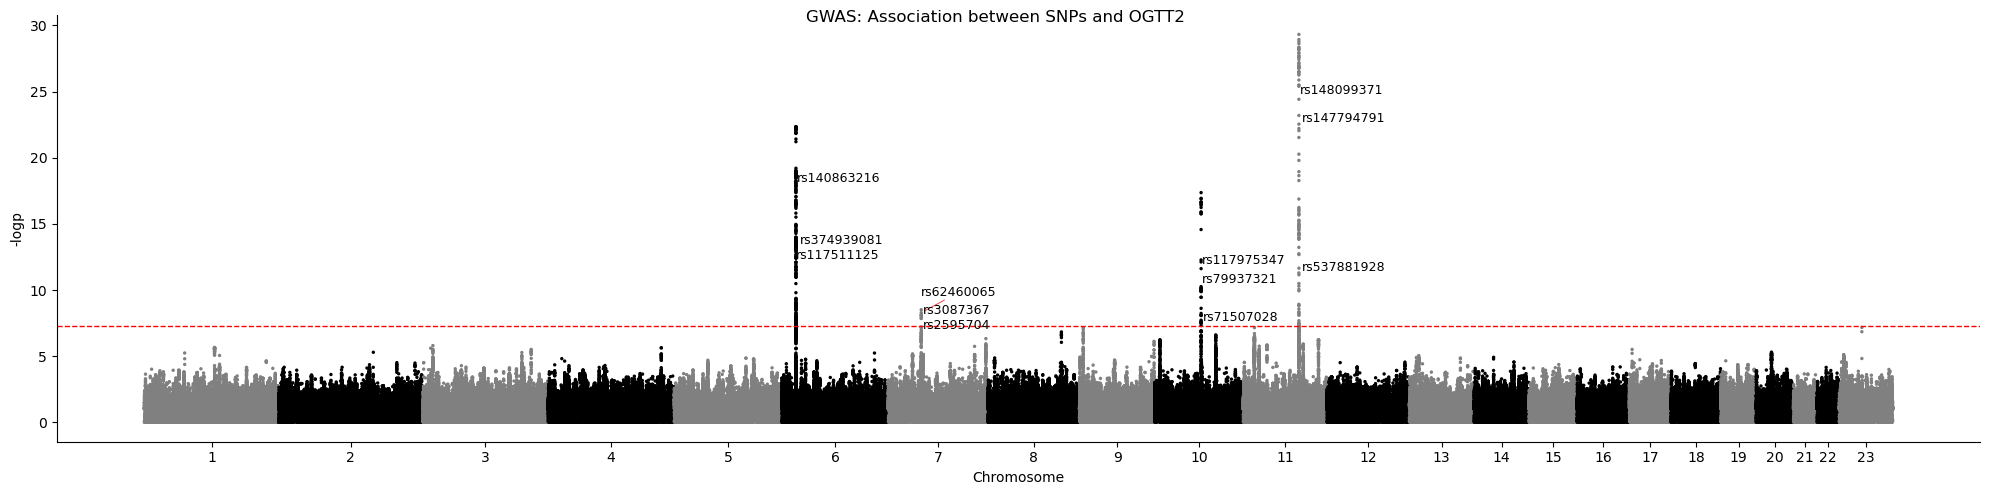

In [8]:
# Thinning the data
sig_snps = df[df['-logp'] > 1] # AI Generated
non_sig_snps = df[df['-logp'] <= 5].sample(frac=0.01, random_state=42) # AI Generated
# Just learned that the random_state of 42 is a reference to one of my favorite books Hitchiker's Guide to the Galaxy!

# Combining
all_snps = pd.concat([sig_snps, non_sig_snps]).sort_values('SNP Number_Updated')

# Plotting
g = sns.relplot(
    data = all_snps,
    x = 'SNP Number_Updated',
    y = '-logp',
    aspect = 4,
    hue = 'chromosome',
    palette = ['grey', 'black'] * 11,
    linewidth = 0,
    s = 6,
    legend=None
)

# Finding top 3 SNPs per chromosome to label
# We group by chromosome and take the top 3 largest -logp values
top_snps = (all_snps[all_snps['-logp'] > 7.30] # Only consider genome-wide significant
            .sort_values('beta', ascending=False) # Sort by beta
            .groupby('chromosome') # Group by chromosome
            .head(3)) # Pick the top three SNPs from each chromosome that are above 5e-8
# This ^ code was AI inspired but not AI generated. AI was used to help me think how to plot only a few SNPs from each linkage disequilibrium

# Adding Annotations
texts = []
for i, row in top_snps.iterrows():
    texts.append(g.ax.text(row['SNP Number_Updated'], row['-logp'], row['rs_id'], fontsize=9))
# This loop was AI generated. The previous code for adding text to our plots would not work, even with updated parameters.

# Styling the plot
g.ax.set_xlabel('Chromosome')
g.ax.set_xticks(df.groupby('chromosome')['SNP Number_Updated'].median())
g.ax.set_xticklabels(df['chromosome'].unique())
g.fig.suptitle('GWAS: Association between SNPs and OGTT2')

# Adding a significance line
g.ax.axhline(-np.log10(5e-8), color='red', linestyle='--', linewidth=1)

# Adjust text to prevent overlap
adjust_text(texts, arrowprops={'arrowstyle': '->', 'color': 'red', 'lw': 0.5})

plt.show()

In [9]:
# Import package for dbSNP variant information
from biothings_client import get_client

# Initialize variant client
mv = get_client('variant')

# List of rs_id's from significant and high beta values in Manhattan plot
rsids = top_snps['rs_id']

# Querying results for these rs_ids
results = mv.querymany(rsids, 
                       scopes='dbsnp.rsid', 
                       fields='dbsnp.gene,snpeff.ann.consequence,snpeff.ann.genename', 
                       species='human')

# Cleaning the data (AI Generated)
processed_data = []
for entry in results:
    rsid = entry.get('query')
    
    snpeff_info = entry.get('snpeff', {}).get('ann', [{}])
    if isinstance(snpeff_info, dict): snpeff_info = [snpeff_info] # handle single return
    
    gene = snpeff_info[0].get('genename') or entry.get('dbsnp', {}).get('gene', {}).get('name', 'N/A')
    
    # Extract Mutation Type (Consequence)
    consequence = snpeff_info[0].get('consequence', 'intergenic/unknown')
    
    processed_data.append({
        'rs_id': rsid,
        'gene': gene,
        'mutation_type': consequence
    }) # End AI Generation

df_annotated = pd.DataFrame(processed_data)
print(df_annotated)
# Manually verified by searching each dbsnp up at https://www.ncbi.nlm.nih.gov/snp/ . Confirmed that none of these SNPs exist in the coding region of genes.

5 input query terms found dup hits:	[('rs140863216', 2), ('rs117511125', 2), ('rs2595704', 3), ('rs62460065', 2), ('rs3087367', 2)]


          rs_id                 gene       mutation_type
0   rs537881928               MTNR1B  intergenic/unknown
1   rs148099371  LOC105369431-MTNR1B  intergenic/unknown
2   rs140863216               CDKAL1  intergenic/unknown
3   rs140863216               CDKAL1  intergenic/unknown
4   rs147794791  LOC105369431-MTNR1B  intergenic/unknown
5   rs374939081               CDKAL1  intergenic/unknown
6   rs117511125               CDKAL1  intergenic/unknown
7   rs117511125               CDKAL1  intergenic/unknown
8   rs117975347         LOC101928994  intergenic/unknown
9    rs79937321         LOC101928994  intergenic/unknown
10   rs71507028         LOC101928994  intergenic/unknown
11    rs2595704                AEBP1  intergenic/unknown
12    rs2595704                AEBP1  intergenic/unknown
13    rs2595704                AEBP1  intergenic/unknown
14   rs62460065              MIR4649  intergenic/unknown
15   rs62460065              MIR4649  intergenic/unknown
16    rs3087367                

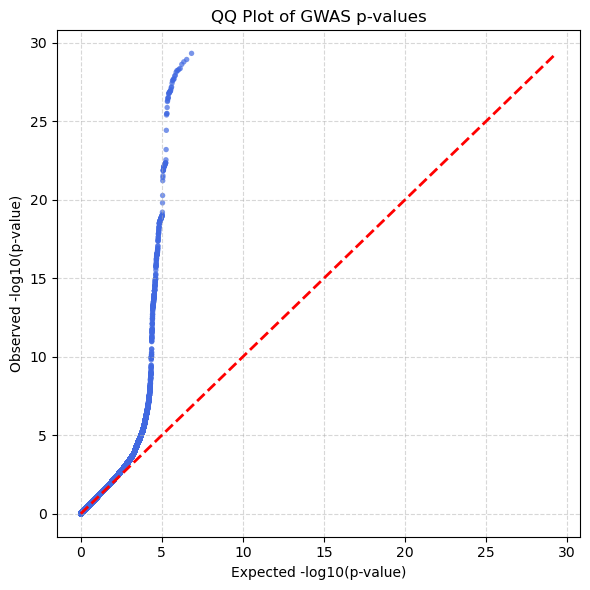

In [10]:
# Similar sampling technique for QQ Plot.

# Find the total number of SNPs in our data set and sort our data's SNPs by their -log10(p)
n_snps = len(df)
obs_log10 = np.sort(df['-logp'])

# Create the null distribution
expected_p = np.arange(1, n_snps + 1) / (n_snps + 1) # First create an array of all integers between 1 and our number of SNPs
# Then, divide by the total number of SNPs. (Important note: df index is 0-based so we add 1)
exp_log10 = -np.log10(expected_p[::-1]) # AI Generated to figure out how to reverse the sort. This line turns the expected_p array into their -log10(p) and sort from smallest to largest

# Thinning the data
sig_mask = obs_log10 > 2 # Take only significant data points stored in this variable (p < 0.01)
sig_idx = np.where(sig_mask)[0] # Finds the array values for each significant SNP
non_sig_idx = np.where(~sig_mask)[0] # Finds the array values for each non-significant SNP (~ = False)

sampled_non_sig_idx = non_sig_idx[::100] # Takes every 100th point from the non-significant SNP data array

plot_idx = np.concatenate([sig_idx, sampled_non_sig_idx]) # Creates a single unified array of significant and sampled non-significant SNPs

plt.figure(figsize=(6, 6))

# Plot the thinned points
plt.scatter(
    x = exp_log10[plot_idx], 
    y = obs_log10[plot_idx], 
    color = 'royalblue', 
    s = 15,
    alpha = 0.7,
    edgecolors = 'none')

# Add the 45-degree null hypothesis line (y=x)
max_val = max(exp_log10.max(), obs_log10.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2)

plt.title('QQ Plot of GWAS p-values')
plt.xlabel('Expected -log10(p-value)')
plt.ylabel('Observed -log10(p-value)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# p-values converted to chi-squared statistics with 1 degree of freedom (AI used for research and understanding of lambda, but not code generation)
chi2 = stats.chi2.ppf(1 - df['p_value'], 1)

# Median chi-squared statistic
median_chi2 = np.nanmedian(chi2)

# Lambda calculation using chi-squared distribution with 1 degree of freedom (0.456)
lamb = median_chi2 / 0.456

print(f"Genomic Inflation Factor (Lambda): {lamb:.4f}")

Genomic Inflation Factor (Lambda): 1.0493
